**Content Investment Strategy & Valuation Model**

Using python-simulated budgets, modeled ROI to determine investment effiency and how it should inform greenlight decisions.

In [ ]:
#IMPORT libraries
import pandas as pd
import matplotlib as plt

In [ ]:
#IMPORT source file
from google.colab import files
uploaded = files.upload()

Saving Content_Valuation.csv to Content_Valuation.csv


In [ ]:
#CHECK File loaded corectly
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Title,Genre,Budget,BoxOffice_Revenue,ROI,ROI_Multiple,Greenlight_Flag,Investment_Bucket
0,Inside Out 2,Animation,"119,868,566.00","1,698,772,985.00",13.171964,14.171964,Greenlight,High Budget
1,Deadpool & Wolverine,Action,"94,469,428.00","1,338,073,645.00",13.164092,14.164092,Greenlight,Mid Budget
2,Despicable Me 4,Animation,"125,907,542.00","969,126,452.00",6.697128,7.697128,Greenlight,High Budget
3,Moana 2,Animation,"160,921,194.00","896,608,683.00",4.571725,5.571725,Greenlight,High Budget
4,Dune: Part Two,Science Fiction,"90,633,865.00","714,444,358.00",6.882753,7.882753,Greenlight,Mid Budget


In [ ]:
#CHECK columns
df.columns

Index(['Title', 'Genre', 'Budget', 'BoxOffice_Revenue', 'ROI', 'ROI_Multiple',
       'Greenlight_Flag', 'Investment_Bucket'],
      dtype='object')

In [ ]:
#CHECK data types
df[['Budget','BoxOffice_Revenue','ROI_Multiple']].dtypes

,0
Budget,object
BoxOffice_Revenue,object
ROI_Multiple,float64


In [ ]:
#CLEAN data types
df['Budget'] = df['Budget'].replace('[\$,]', '', regex=True).astype(float)
df['BoxOffice_Revenue'] = df['BoxOffice_Revenue'].replace('[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_5015/3432751039.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Budget'] = df['Budget'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_5015/3432751039.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['BoxOffice_Revenue'] = df['BoxOffice_Revenue'].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
#CONFIRM data type change
df[['Budget','BoxOffice_Revenue']].dtypes

,0
Budget,float64
BoxOffice_Revenue,float64


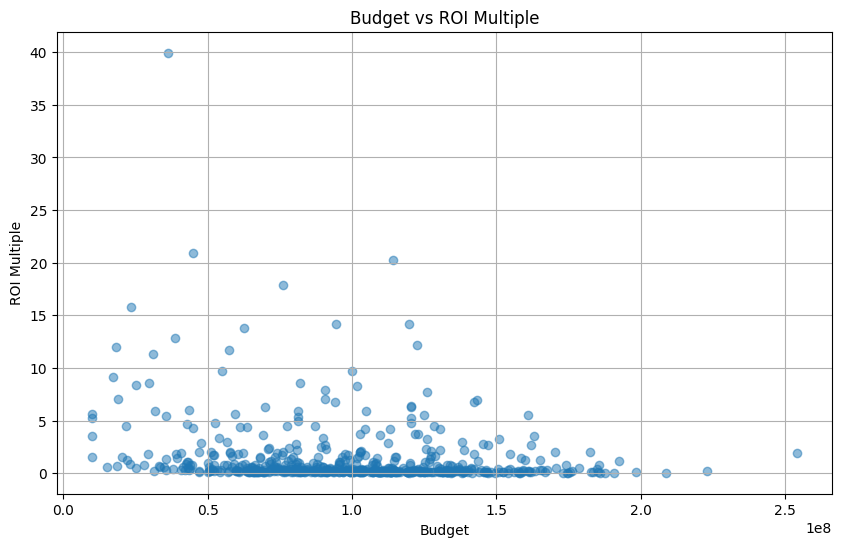

In [ ]:
#BUILD visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df['Budget'], df['ROI_Multiple'], alpha=0.5)

plt.title('Budget vs ROI Multiple')
plt.xlabel('Budget')
plt.ylabel('ROI Multiple')
plt.grid(True)

plt.show()

In [ ]:
#FIX Error - restart matplotlib
import matplotlib.pyplot as plt

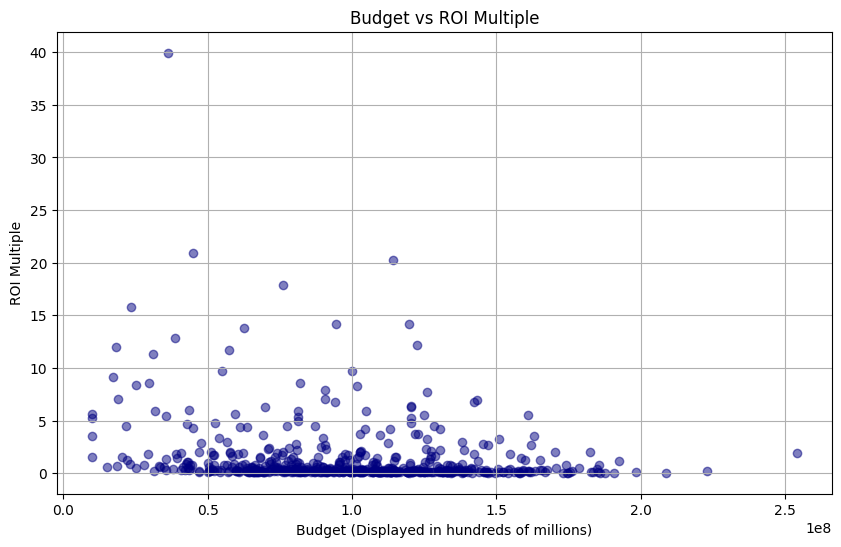

In [ ]:
#RUN Scatterplot
plt.figure(figsize=(10,6))
plt.scatter(df['Budget'], df['ROI_Multiple'], alpha=0.5,color='navy')

plt.title('Budget vs ROI Multiple')
plt.xlabel('Budget (Displayed in hundreds of millions)')
plt.ylabel('ROI Multiple')
plt.grid(True)

plt.show()

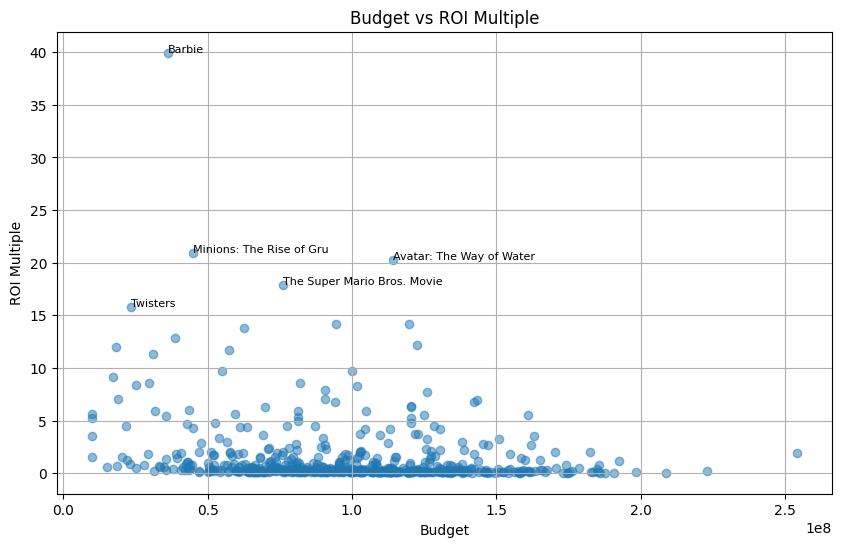

In [ ]:
#IDENTIFY top performers
top = df.nlargest(5, 'ROI_Multiple')

plt.figure(figsize=(10,6))
plt.scatter(df['Budget'], df['ROI_Multiple'], alpha=0.5)

for _, row in top.iterrows():
    plt.text(row['Budget'], row['ROI_Multiple'], row['Title'], fontsize=8)

plt.title('Budget vs ROI Multiple')
plt.xlabel('Budget')
plt.ylabel('ROI Multiple')
plt.grid(True)

plt.show()

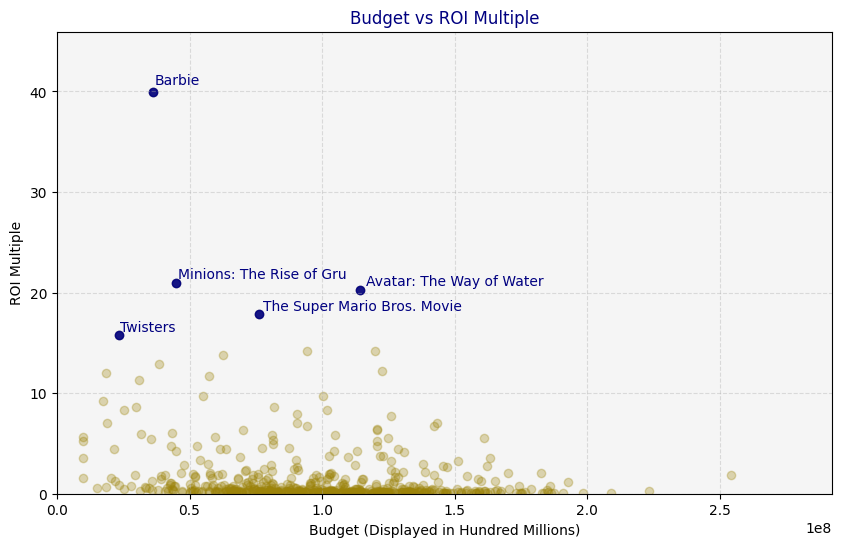

In [ ]:
#FORMAT chart
plt.figure(figsize=(10,6))
plt.gca().set_facecolor('#f5f5f5')

plt.scatter(df['Budget'], df['ROI_Multiple'], alpha=0.3,color='#9c8309')
plt.scatter(top['Budget'], top['ROI_Multiple'], alpha=0.9,color='navy')

for _, row in top.iterrows():
    plt.text(row['Budget']*1.02, row['ROI_Multiple']*1.02, row['Title'],
             fontsize=10,color='navy')

plt.title('Budget vs ROI Multiple',color='navy')
plt.xlabel('Budget (Displayed in Hundred Millions)')
plt.ylabel('ROI Multiple')

plt.grid(True, linestyle='--', alpha=0.4)

plt.xlim(0, df['Budget'].max()*1.15)
plt.ylim(0, df['ROI_Multiple'].max()*1.15)

plt.show()

In [ ]:
#SUMMARY table by budget bucket
bucket_summary = df.groupby('Investment_Bucket').agg(
    Avg_Budget=('Budget', 'mean'),
    Avg_Revenue=('BoxOffice_Revenue', 'mean'),
    Avg_ROI=('ROI', 'mean'),
    Avg_ROI_Multiple=('ROI_Multiple', 'mean'),
    Title_Count=('Title', 'count')
).reset_index()

bucket_summary

,Investment_Bucket,Avg_Budget,Avg_Revenue,Avg_ROI,Avg_ROI_Multiple,Title_Count
0,High Budget,1.302869e+08,1.228405e+08,-0.027787,0.972213,287
1,Low Budget,3.301024e+07,1.312293e+08,3.189233,4.189233,53
2,Mid Budget,7.682987e+07,9.098206e+07,0.211819,1.211819,231


In [ ]:
#FIX display
bucket_summary.style.format({
    'Avg_Budget': '${:,.0f}',
    'Avg_Revenue': '${:,.0f}',
    'Avg_ROI': '{:.2f}',
    'Avg_ROI_Multiple': '{:.2f}',
    'Title_Count': '{:,}'
})

,Investment_Bucket,Avg_Budget,Avg_Revenue,Avg_ROI,Avg_ROI_Multiple,Title_Count
0,High Budget,"$130,286,861","$122,840,481",-0.03,0.97,287
1,Low Budget,"$33,010,238","$131,229,327",3.19,4.19,53
2,Mid Budget,"$76,829,867","$90,982,058",0.21,1.21,231


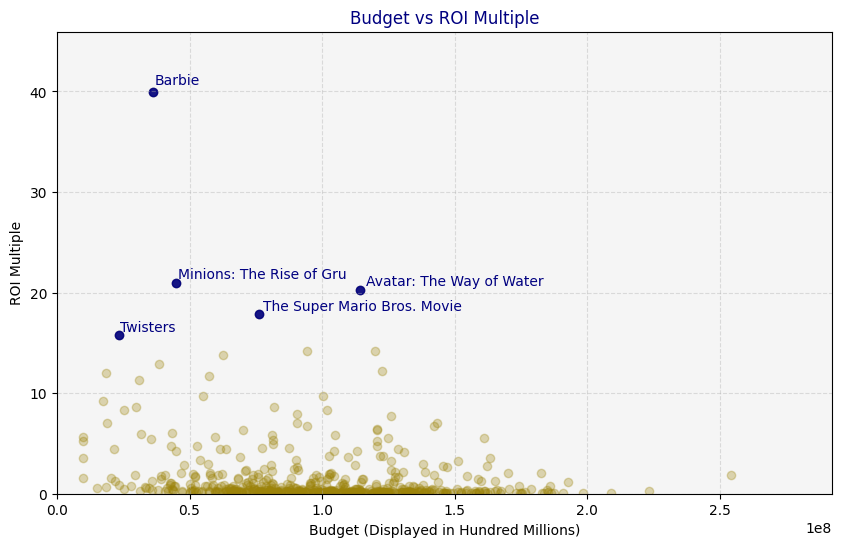

In [ ]:
#DISPLAY scatterplot for analysis

plt.figure(figsize=(10,6))
plt.gca().set_facecolor('#f5f5f5')

plt.scatter(df['Budget'], df['ROI_Multiple'], alpha=0.3,color='#9c8309')
plt.scatter(top['Budget'], top['ROI_Multiple'], alpha=0.9,color='navy')

for _, row in top.iterrows():
    plt.text(row['Budget']*1.02, row['ROI_Multiple']*1.02, row['Title'],
             fontsize=10,color='navy')

plt.title('Budget vs ROI Multiple',color='navy')
plt.xlabel('Budget (Displayed in Hundred Millions)')
plt.ylabel('ROI Multiple')

plt.grid(True, linestyle='--', alpha=0.4)

plt.xlim(0, df['Budget'].max()*1.15)
plt.ylim(0, df['ROI_Multiple'].max()*1.15)

plt.savefig("roi_chart.png", dpi=300, bbox_inches='tight')
plt.show()

**Key Insights**


*   Lower budget films generate the highest ROI compared to higher budget films (~4x ROI multiple on average)
*   Mid budget films generate positive ROI on average, but still significantly lower than low-budget films at an average ROI multiple of ~1x.
*   Higher budget films average the biggest losses, with a negative ROI multiple on average which suggests potential overinvestment with diminishing returns.





